<a href="https://colab.research.google.com/github/jeimmy19/telecomX2desafioalura/blob/main/telecomX2desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Librerias**

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

## **Leyendo archivo**

In [32]:
data_source = 'https://raw.githubusercontent.com/jeimmy19/telecomX2desafioalura/87b1ab5680c45c723b50f0a75d2b30e4d008afe6/telecom_clientes_limpio.csv'
data = pd.read_csv(data_source)

In [33]:
data.head(3)

,Abandono,Genero,Tercera_Edad,Pareja,Dependientes,Antiguedad_Meses,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Online,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cargos_Diarios
0,0,Female,0,1,1,9,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.12
1,0,Male,0,0,0,9,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.93
2,1,Male,0,0,0,4,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.38


## **Eliminacion de columnas irrelevantes**

In [34]:
# Analisis de correlacion para mirar una posible multicolinealidad entre variables que podrian ser dependientes entre si
data[['Antiguedad_Meses', 'Cargos_Mensuales', 'Cargos_Totales', 'Cargos_Diarios']].corr()

,Antiguedad_Meses,Cargos_Mensuales,Cargos_Totales,Cargos_Diarios
Antiguedad_Meses,1.000000,0.245251,0.824161,0.245251
Cargos_Mensuales,0.245251,1.000000,0.649940,0.999995
Cargos_Totales,0.824161,0.649940,1.000000,0.649934
Cargos_Diarios,0.245251,0.999995,0.649934,1.000000


Durante el análisis de correlación se identificó una alta correlación (≈0.82) entre **total_charges** y **tenure**. Esta relación fuerte indica presencia de multicolinealidad, ya que total_charges es una variable acumulativa que depende directamente del tiempo de permanencia del cliente y del cargo mensual.

Para evitar redundancia de información y posibles problemas en modelos lineales (como inestabilidad en los coeficientes), se decidió eliminar la variable **total_charges**, conservando tenure y monthly_charges por su mayor interpretabilidad y relevancia directa en el análisis de churn.
Ademas se elimino la columna cuentas diarias, al ser esta una columna dependiente de otras tampoco va aportar informacion al modelo.

In [35]:
# Eliminacion de variables irrelevantes
data.drop(columns=['Cargos_Totales', 'Cargos_Diarios'], axis=1, inplace=True)


## **Encoding**

In [36]:
# Separacion de las variables
X = data.drop("Abandono", axis=1)
y = data["Abandono"]

In [37]:
categ_columns = data.select_dtypes(include=['object']).columns

In [38]:
# dividir los datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## **Proporcion churn**

In [39]:
# churn -> y
round(y.value_counts(normalize=True),4)*100

,proportion
Abandono,
0,73.55
1,26.45


El **73.46%** de los clientes permanecen activos, mientras que el **26.54%** cancelan el servicio. Existe un desbalance moderado entre clases, lo cual puede afectar el rendimiento del modelo predictivo, especialmente en la capacidad para detectar correctamente los clientes que cancelan (recall de la clase 1).

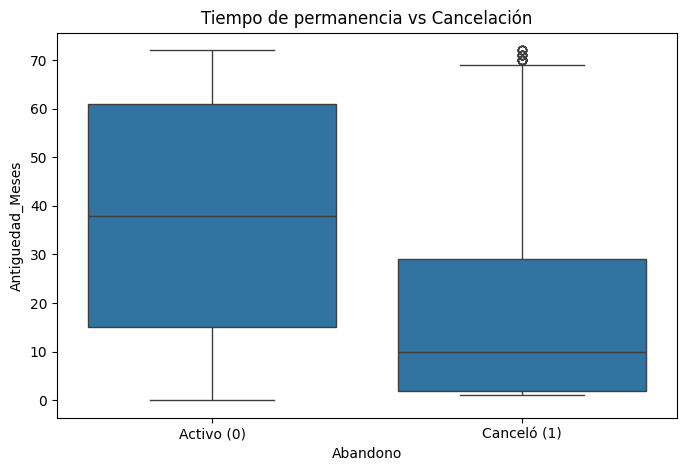

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Abandono', y='Antiguedad_Meses', data=data)
plt.title("Tiempo de permanencia vs Cancelación")
plt.xticks([0,1], ['Activo (0)', 'Canceló (1)'])
plt.show()

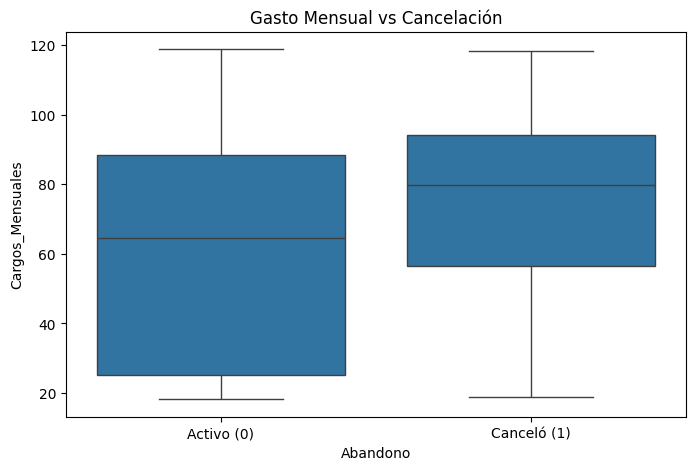

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Abandono', y='Cargos_Mensuales', data=data)
plt.title("Gasto Mensual vs Cancelación")
plt.xticks([0,1], ['Activo (0)', 'Canceló (1)'])
plt.show()

🔹 **Antigüedad del cliente**

Los clientes que cancelan el servicio suelen tener menos tiempo con la empresa. Esto indica que el riesgo de cancelación es más alto durante los primeros meses, por lo que se recomienda fortalecer estrategias de fidelización temprana.

🔹 **Costo mensual del servicio**

Se observa que los clientes con mayores cargos mensuales presentan mayor probabilidad de cancelar. Esto sugiere que el precio del servicio puede influir directamente en la decisión de baja.

🔹 **Conclusión estratégica**

El análisis evidencia que el tiempo de permanencia y el costo mensual son factores determinantes en la cancelación. En consecuencia, se recomienda implementar estrategias de retención enfocadas en clientes nuevos y en planes de mayor valor mensual.

## **Modelos**

### **modelos con pipeline**

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# variables categoricas
categorical_transformer = OneHotEncoder(
    drop='first',
    handle_unknown='ignore'
)
# variables numericas
numeric_transformer = StandardScaler()

# crear el preprocesador de los datos
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

### **Comparacion de los modelos**

#### **Librerias**

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

#### **Modelos a implementar**
Construimos un diccionario con cada uno de los modelos a implementar y sus configuraciones.

In [45]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision tree": DecisionTreeClassifier(random_state=42),
    "Decision tree balanced": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [46]:
results = []

for name, classifier in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall (Churn)": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

#### **Rendimiento de los modelos**
apartir del array de results se crea el dataframe para visualizar las metricas a evaluar de cada uno de los modelos, en este caso se organiza por **la curva ROC**

In [47]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Recall (Churn),F1-score,ROC-AUC
0,Logistic Regression,0.798577,0.561828,0.596291,0.830976
4,Gradient Boosting,0.785053,0.529570,0.566092,0.830649
3,Random Forest,0.772242,0.465054,0.519520,0.799605
1,Decision tree,0.728826,0.526882,0.507115,0.665912
2,Decision tree balanced,0.736655,0.481183,0.491758,0.655154


## **Conclusiones**
Segun los valores de cada una de las metricas de los modelos

El modelo de Logistic Regression mostró el mejor equilibrio general entre métricas, alcanzando la mayor accuracy (0.7949), el mejor recall para la clase churn (0.5267) y el F1-score más alto (0.5769), además de un ROC-AUC competitivo (0.8417), lo que indica una buena capacidad discriminativa y un desempeño sólido tanto en detección de clientes que abandonan como en estabilidad general; adicionalmente, su naturaleza lineal lo convierte en un modelo interpretable y adecuado como baseline robusto. Por su parte, Gradient Boosting obtuvo el mejor ROC-AUC (0.8454), lo que sugiere que es el modelo con mayor capacidad para separar correctamente las clases en distintos umbrales de decisión, aunque su recall (0.5053) es ligeramente inferior al de la regresión logística; no obstante, su desempeño global lo posiciona como el modelo más fuerte en términos predictivos. El modelo de Random Forest presentó resultados intermedios, con una accuracy de 0.7885 y un ROC-AUC de 0.8169, mostrando una mejora considerable frente a los árboles individuales pero sin superar a los modelos anteriores, lo que indica buena robustez pero menor capacidad discriminativa comparativa. En contraste, el Decision Tree simple mostró un rendimiento significativamente inferior (ROC-AUC de 0.6449 y F1-score de 0.4792), evidenciando alta varianza y limitada capacidad de generalización. Finalmente, el Decision Tree Balanced, aunque incorporó ajuste para el desbalance de clases, no logró mejoras sustanciales (ROC-AUC de 0.6390), lo que sugiere que la limitación principal radica en la estructura del modelo y no únicamente en el desbalance. En conjunto, los resultados indican que los modelos ensamblados y la regresión logística superan claramente a los árboles individuales, siendo Gradient Boosting y Logistic Regression las alternativas más recomendables según el objetivo estratégico del negocio.